# Customer Retention Analysis

This notebook visualizes customer retention across cohorts based on the month of each customer's first observed transaction.

The retention metrics are calculated in PostgreSQL and accessed through the `analytics.cohort_retention` view. Python is used to transform the results into a retention matrix and visualize cohort behavior over time.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from dotenv import load_dotenv

In [3]:
print(os.getenv("FINSIGHT_DB_PASSWORD") is not None)

True


In [2]:
load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [3]:
with engine.connect() as connection:
    print("Connected!")

Connected!


In [13]:
query = """
select *
from analytics.cohort_retention
order by cohort_month, months_since_first_transaction
"""

df = pd.read_sql(query, engine)

In [9]:
df.head()


,cohort_month,months_since_first_transaction,active_customers,cohort_size,retention_rate
0,2010-01-01,0.0,1083,1083,100.0
1,2010-01-01,1.0,1083,1083,100.0
2,2010-01-01,2.0,1083,1083,100.0
3,2010-01-01,3.0,1083,1083,100.0
4,2010-01-01,4.0,1083,1083,100.0


In [14]:
retention_matrix = pd.pivot_table(
    df,
    index="cohort_month",
    columns="months_since_first_transaction",
    values="retention_rate"
)

In [15]:
retention_matrix.head()

months_since_first_transaction,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,108.0,109.0,110.0,111.0,112.0,113.0,114.0,115.0,116.0,117.0
cohort_month,,,,,,,,,,,,,,,,,,,,,
2010-01-01,100.0,100.00,100.00,100.00,100.00,100.00,100.00,99.91,99.91,99.91,...,98.8,98.8,98.89,98.89,98.89,98.89,98.89,98.89,98.89,98.61
2010-02-01,100.0,71.43,78.57,78.57,92.86,92.86,92.86,100.00,100.00,100.00,...,100.0,100.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,NaN
2010-03-01,100.0,75.00,75.00,75.00,75.00,75.00,75.00,75.00,100.00,100.00,...,100.0,100.0,100.00,100.00,100.00,100.00,100.00,100.00,NaN,NaN
2010-04-01,100.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,...,100.0,100.0,100.00,100.00,100.00,100.00,100.00,NaN,NaN,NaN
2010-05-01,100.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,...,100.0,100.0,100.00,100.00,100.00,100.00,NaN,NaN,NaN,NaN


In [16]:
retention_12m = retention_matrix.iloc[:, :12]

In [17]:
retention_12m.head()

months_since_first_transaction,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0
cohort_month,,,,,,,,,,,,
2010-01-01,100.0,100.00,100.00,100.00,100.00,100.00,100.00,99.91,99.91,99.91,99.91,99.91
2010-02-01,100.0,71.43,78.57,78.57,92.86,92.86,92.86,100.00,100.00,100.00,100.00,100.00
2010-03-01,100.0,75.00,75.00,75.00,75.00,75.00,75.00,75.00,100.00,100.00,100.00,100.00
2010-04-01,100.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2010-05-01,100.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00


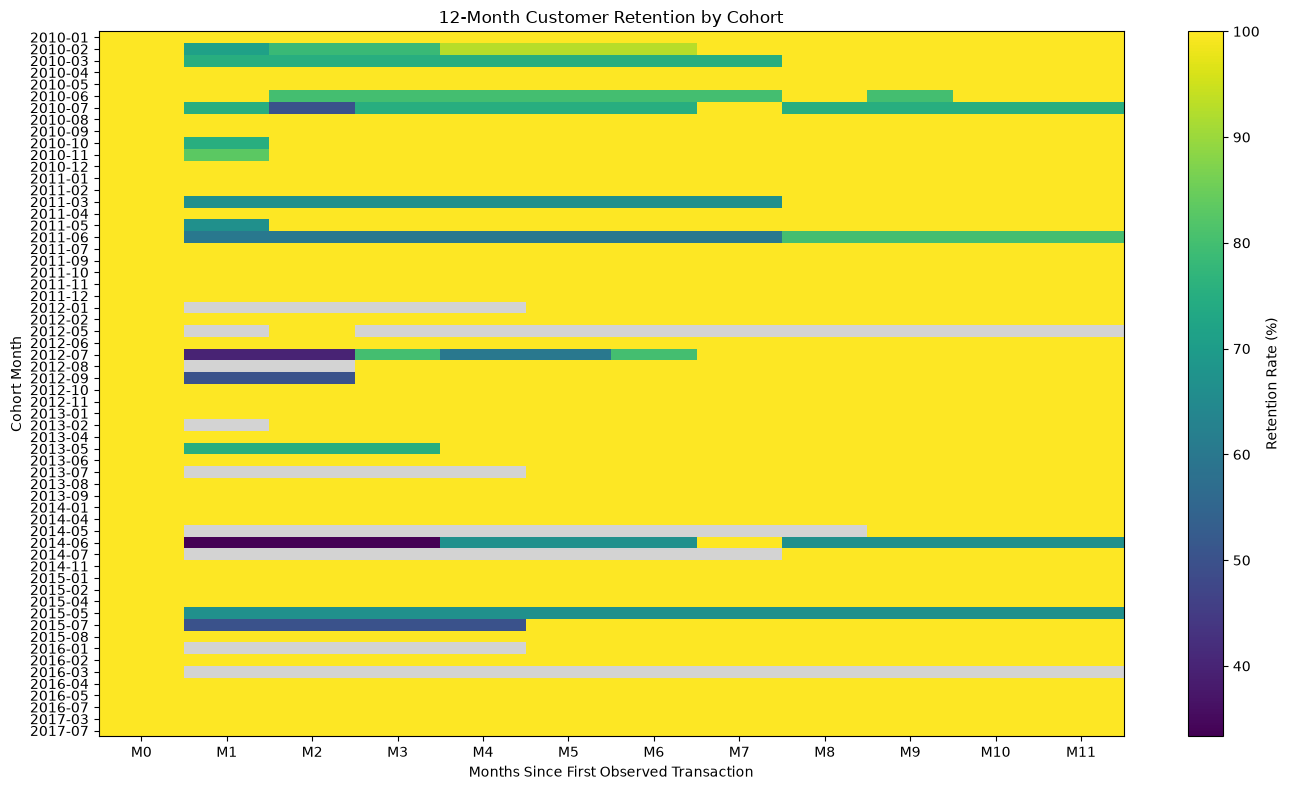

In [22]:
fig, ax = plt.subplots(figsize=(14, 8))

cmap = plt.colormaps["viridis"].copy()
cmap.set_bad("lightgray")

im = ax.imshow(
    retention_12m,
    aspect="auto",
    cmap=cmap
)

fig.colorbar(
    im,
    ax=ax,
    label="Retention Rate (%)"
)

ax.set_title("12-Month Customer Retention by Cohort")
ax.set_xlabel("Months Since First Observed Transaction")
ax.set_ylabel("Cohort Month")

ax.set_xticks(range(retention_12m.shape[1]))
ax.set_xticklabels(
    [f"M{int(col)}" for col in retention_12m.columns]
)

ax.set_yticks(range(retention_12m.shape[0]))
ax.set_yticklabels(
    [date.strftime("%Y-%m") for date in retention_12m.index]
)

plt.tight_layout()
plt.show()